In [ ]:
from valdpy import ValdAuth, ForceFrameAPI
from valdpy.utils import read_credentials

%load_ext autoreload
%autoreload 2

# ForceFrame API Example

This example demonstrates how to use the VALDPY package to access ForceFrame (advanced force measurement) test data.

In [ ]:
creds = read_credentials('vald_api_cred.txt')
client_id = creds['client_id']
client_secret = creds['client_secret']
tenant_id = creds['tenant_id']
print(f"Client ID: {client_id[:10]}...")
print(f"Tenant ID: {tenant_id}")

Client ID: 
Client Secret: 
Tenant ID: 


## Step 1: Authentication

In [ ]:
auth = ValdAuth(client_id, client_secret, tenant_id=tenant_id, region='USA')

### Get OAuth Access Token

In [ ]:
token = auth.get_token()
print(f"Token obtained: {token[:20]}...")

### Optional: Get Tenant Information

In [ ]:
all_tenants = auth.get_all_tenants()
print(f"Found {len(all_tenants)} tenant(s)")

In [ ]:
tenant_info = auth.get_tenant_info()
print(f"Tenant Name: {tenant_info.get('name')}")
print(f"Tenant ID: {tenant_info.get('id')}")

## Step 2: Get Categories and Groups

In [ ]:
categories_df = auth.get_tenant_categories()
print(categories_df[['name', 'id']].to_string(index=False))

,id,syncId,name
0,306f33af-2939-480b-bbd7-2ce643c888f0,None,Uncategorised
1,3a32a047-1292-49f1-a8aa-8f830ea58ac8,None,Position
2,1fdaf750-970a-4047-badc-945e6e6994cf,None,Team
3,2828d5d2-ce26-4297-b4c1-a16039889a86,None,Sport


In [ ]:
groups_df = auth.get_tenant_groups()
print(f"Found {len(groups_df)} group(s)")
print(groups_df[['name', 'id']].head(10).to_string(index=False))

,id,name,categoryId,syncId
0,286167da-0a3c-4da9-9b09-316ba9f6e089,Acro and Tumbling,1fdaf750-970a-4047-badc-945e6e6994cf,None
1,61694101-179d-483f-a8c7-8c5632362760,Acro and Tumbling,2828d5d2-ce26-4297-b4c1-a16039889a86,None
2,20588edf-7394-489c-a502-1f0c10c25db8,Baseball,2828d5d2-ce26-4297-b4c1-a16039889a86,None
3,f26a6a9c-7232-4d01-a214-b3f8584ba293,Baseball,1fdaf750-970a-4047-badc-945e6e6994cf,None
4,fa4489a4-4a0e-4003-869d-3a7565e82fe4,Football,2828d5d2-ce26-4297-b4c1-a16039889a86,None


## Step 3: Get Profiles

In [ ]:
group_name = 'Research'
category_name = 'Team'

try:
    profiles_df = auth.get_group_profiles(group_name=group_name, category_name=category_name)
    print(f"Found {len(profiles_df)} profile(s)")
    print(profiles_df[['firstName', 'lastName', 'profileId']].head(10).to_string(index=False))
except Exception as e:
    print(f"Error: {e}")

## Step 4: Initialize ForceFrame API

In [ ]:
ff = ForceFrameAPI(tenant_id=auth.tenant_id, header=auth.header, region='USA')

### Get Test Information

In [ ]:
date = '01/01/2025'
tests_df = ff.get_tests_info(date)

if tests_df is not None:
    print(f"Found {len(tests_df)} test(s)")
    print(tests_df[['testId', 'profileId']].head())
else:
    print("No tests found")

{'/tests/v2': '', '?TenantId=': '61476d2d-917a-4b2e-b2f6-e43346d2cb66', '&ModifiedFromUtc=': '2026-05-18T05%3A00%3A00.000Z', '&ProfileId=': 'b087502b-e06f-46c2-8ce0-11fd2817b416'}
<Response [200]>
{'/tests/v2': '', '?TenantId=': '61476d2d-917a-4b2e-b2f6-e43346d2cb66', '&ModifiedFromUtc=': '2026-05-19T18%3A22%3A02.9075819Z', '&ProfileId=': 'b087502b-e06f-46c2-8ce0-11fd2817b416'}
204
Request Completed.


,profileId,testId,testDateUtc,testTypeId,testPositionId,notes,innerLeftAvgForce,innerLeftImpulse,innerLeftMaxForce,innerLeftRepetitions,...,outerLeftMaxForce,outerLeftRepetitions,outerRightAvgForce,outerRightImpulse,outerRightMaxForce,outerRightRepetitions,device,modifiedDateUtc,testTypeName,testPositionName
0,b087502b-e06f-46c2-8ce0-11fd2817b416,d98b9897-079f-43ed-a218-562dba2a38c4,2026-05-19T18:19:12.938Z,fa9eef53-f8a3-4257-9d59-6533443513be,0193ca1d-89fb-480e-b2bc-b5e5d8cb52dd,,175.25,735.835625,218.25,2,...,270.75,1,247.0,504.099063,247.0,1,ForceFrame-2864,2026-05-19T18:19:13.1277350Z,Hip AD/AB,Hip AD/AB - 45
1,b087502b-e06f-46c2-8ce0-11fd2817b416,ad2359cd-e9d2-4ea1-8084-d234ff490924,2026-05-19T18:21:57.189Z,fa9eef53-f8a3-4257-9d59-6533443513be,0193ca1d-89fb-480e-b2bc-b5e5d8cb52dd,,171.25,441.137188,171.25,1,...,0.00,0,85.5,165.909688,85.5,1,ForceFrame-2850,2026-05-19T18:22:02.9075819Z,Hip AD/AB,Hip AD/AB - 45


### Get Test Results

In [ ]:
if tests_df is not None and len(tests_df) > 0:
    test_id = tests_df.iloc[0]['testId']
    results_df = ff.get_test_results(test_id)
    if results_df is not None:
        print(results_df.head())
    else:
        print("No results available")

{'athleteId': 'b087502b-e06f-46c2-8ce0-11fd2817b416',
 'testId': 'd98b9897-079f-43ed-a218-562dba2a38c4',
 'testDateUtc': '2026-05-19T18:19:12.938Z',
 'testTypeId': 'fa9eef53-f8a3-4257-9d59-6533443513be',
 'testPositionId': '0193ca1d-89fb-480e-b2bc-b5e5d8cb52dd',
 'notes': '',
 'innerLeftAvgForce': 175.25,
 'innerLeftImpulse': 735.8356249999383,
 'innerLeftMaxForce': 218.25,
 'innerLeftRepetitions': 2,
 'innerRightAvgForce': 194.125,
 'innerRightImpulse': 827.8571874999107,
 'innerRightMaxForce': 239.25,
 'innerRightRepetitions': 2,
 'outerLeftAvgForce': 270.75,
 'outerLeftImpulse': 554.6412500000868,
 'outerLeftMaxForce': 270.75,
 'outerLeftRepetitions': 1,
 'outerRightAvgForce': 247.0,
 'outerRightImpulse': 504.0990625000788,
 'outerRightMaxForce': 247.0,
 'outerRightRepetitions': 1,
 'device': 'ForceFrame-2864',
 'modifiedDateUtc': '2026-05-19T18:19:13.127Z',
 'testTypeName': 'Hip AD/AB',
 'testPositionName': 'Hip AD/AB - 45'}

### Visualize Results

In [ ]:
if results_df is not None:
    print("Test Results:")
    print(results_df.info())
else:
    print("No data to visualize")

,ticks,innerLeftForce,innerRightForce,outerLeftForce,outerRightForce,datetime,Time
0,639148115529382530,-1.75,-1.25,2.50,-1.00,2026-05-19 18:19:12.938255310+00:00,0.000000
1,639148115529407490,0.00,-0.50,1.25,2.50,2026-05-19 18:19:12.940750122+00:00,0.002495
2,639148115529432580,-1.00,-2.25,2.25,1.25,2026-05-19 18:19:12.943260193+00:00,0.005005
3,639148115529457540,-2.25,-1.25,3.00,0.25,2026-05-19 18:19:12.945755005+00:00,0.007500
4,639148115529482500,-1.50,0.25,1.75,1.50,2026-05-19 18:19:12.948249817+00:00,0.009995


<Axes: title={'center': 'Inner Left Force Trace'}, xlabel='Time (s)', ylabel='Force (N)'>

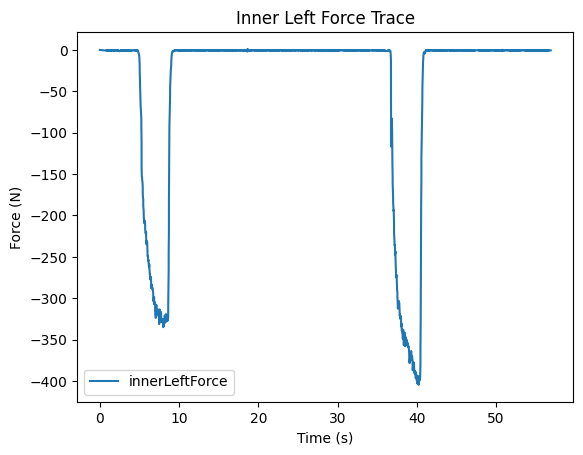

In [ ]:
import matplotlib.pyplot as plt
if results_df is not None and len(results_df) > 0:
    results_df.head(10).plot(kind='bar')
    plt.title('ForceFrame Test Results')
    plt.show()
else:
    print("No data to plot")